# Hard Initial Conds 

Epoch 0 | Train: 1.128396 | Test MSE: 2.703841
Epoch 1000 | Train: 0.149809 | Test MSE: 1.771832
Epoch 2000 | Train: 0.149692 | Test MSE: 1.744426
Epoch 3000 | Train: 0.151550 | Test MSE: 1.777409
Epoch 4000 | Train: 0.149636 | Test MSE: 1.734425
Epoch 5000 | Train: 0.149588 | Test MSE: 1.728917
Epoch 6000 | Train: 0.149530 | Test MSE: 1.725787
Epoch 7000 | Train: 0.149298 | Test MSE: 1.714071
Epoch 8000 | Train: 0.149275 | Test MSE: 1.711672
Epoch 9000 | Train: 0.147468 | Test MSE: 1.654247
Epoch 10000 | Train: 0.146471 | Test MSE: 2.153054
Epoch 11000 | Train: 0.164423 | Test MSE: 3.046606
Epoch 12000 | Train: 0.000503 | Test MSE: 0.000613
Epoch 13000 | Train: 0.000438 | Test MSE: 0.000124
Epoch 14000 | Train: 0.001270 | Test MSE: 0.000427
Epoch 15000 | Train: 0.000126 | Test MSE: 0.000173
Epoch 16000 | Train: 0.000513 | Test MSE: 0.000192
Epoch 17000 | Train: 0.003255 | Test MSE: 0.000820
Epoch 18000 | Train: 0.000379 | Test MSE: 0.000169
Epoch 19000 | Train: 0.000270 | Test MSE: 0.

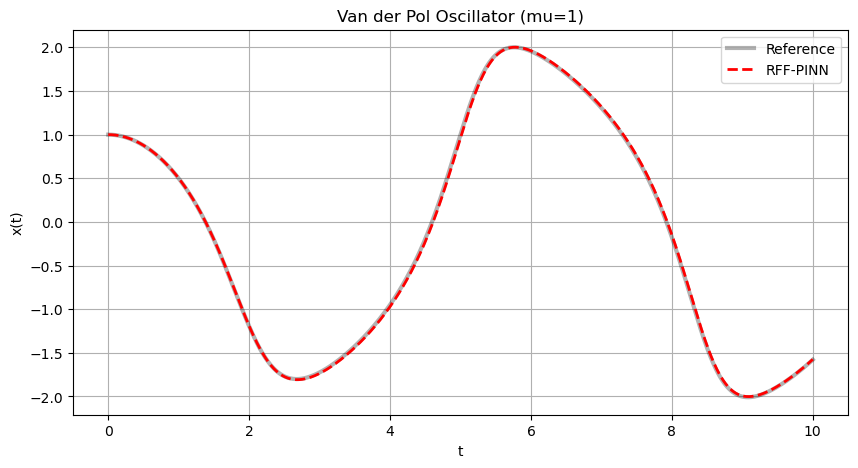

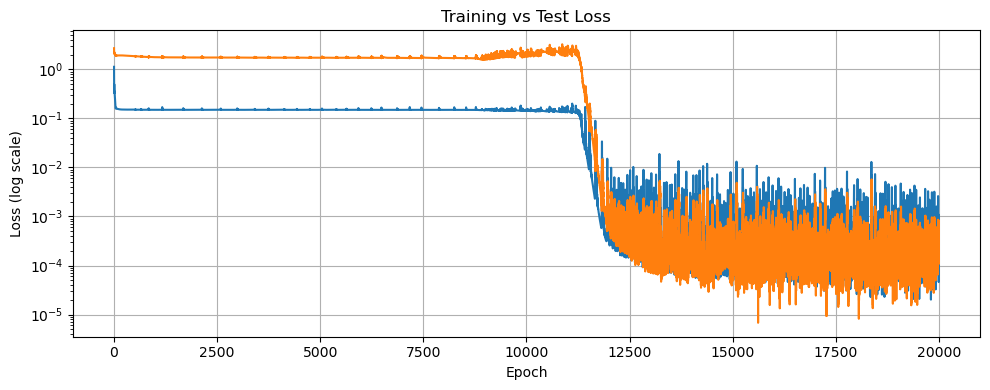

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp

# -----------------------------
# 1. Neural Network
# -----------------------------
class BasicNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------
# 2. Helper functions
# -----------------------------
def d_dt(x, t):
    (dt,) = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)
    return dt

def d2_dt2(x, t):
    dt = d_dt(x, t)
    dtt = d_dt(dt, t)
    return dtt

# y bar transformation
def IVP_transform(model, t, x0, x_p0, t0):
     x_hat_t = model(t)

     x_hat_0 = model(t0)
     xp_hat_0 = d_dt(x_hat_0, t0)
     
     # x_bar
     x_bar = x_hat_t + x0 - x_hat_0 + t * (x_p0 - xp_hat_0)
     return x_bar

# -----------------------------
# 3. Training loop
# -----------------------------
def train_PINN(epochs, model, mu, t_min, t_max, x0, v0, t_test, x_test_true, n_col=1000, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    test_losses = []

    # Initial time (needs grad for x'(t0))
    t0 = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)

    # Collocation points like your linspace approach (fixed, deterministic)
    t_interior_np = np.linspace(t_min, t_max, n_col + 2)[1:-1]  # exclude both boundaries
    t_interior = torch.tensor(t_interior_np, dtype=torch.float32).view(-1, 1)
    t_interior.requires_grad_(True)

    for i in range(epochs):

        x_hat = IVP_transform(model, t_interior, x0, v0, t0)
    
        # 2) residual: y'' + y - sin(pi x)
        x_pp_hat = d2_dt2(x_hat, t_interior)
        x_p_hat = d_dt(x_hat, t_interior)
    
        r = x_pp_hat - mu * (1 - x_hat**2) * x_p_hat + x_hat

        loss = torch.mean(r**2)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        train_losses.append(loss.item())

         # ----- Test loss -----
        model.eval()
        t0_eval = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)
        t_test_req = t_test.clone().detach().requires_grad_(True)

        x_test_pred = IVP_transform(model, t_test_req, x0, v0, t0_eval)
        mse = torch.mean((x_test_pred - x_test_true)**2).item()

        test_losses.append(mse)
        model.train()

        if i % 1000 == 0:
            print(f"Epoch {i} | Train: {loss.item():.6f} | Test MSE: {mse:.6f}")

    return model, train_losses, test_losses

# -----------------------------
# 4. Execution
# -----------------------------
mu = 1
t_min, t_max = 0.0, 10.0
x0, v0 = 1.0, 0.0

# Reference
t_ref = np.linspace(0, 10, 1000)
sol = solve_ivp(lambda t, z: [z[1], mu*(1-z[0]**2)*z[1]-z[0]], [0, 10], [1.0, 0.0], t_eval=t_ref)
x_ref = sol.y[0]

t_test = torch.tensor(t_ref, dtype=torch.float32).view(-1, 1)
x_test_true = torch.tensor(x_ref, dtype=torch.float32).view(-1, 1)

torch.manual_seed(0)
model = BasicNetwork()
trained_model, train_loss_history, test_loss_history = train_PINN(epochs=20000, model=model, mu=mu, t_min=t_min, t_max=t_max, x0=x0, v0=v0, t_test=t_test, x_test_true=x_test_true)

# Train Model
trained_model.eval()

t_plot = torch.linspace(t_min, t_max, 1000).reshape(-1, 1).requires_grad_(True)
t0_plot = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)
    
x_pinn = IVP_transform(trained_model, t_plot, x0, v0, t0_plot).detach().numpy().reshape(-1)



# Plot Results
plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[0], 'k-', alpha=0.3, lw=3, label="Reference")
plt.plot(sol.t, x_pinn, 'r--', lw=2, label="RFF-PINN")
plt.title(f"Van der Pol Oscillator (mu={mu})") 
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.semilogy(train_loss_history, label="Train (physics residual)")
plt.semilogy(test_loss_history, label="Test (MSE vs reference)")
plt.title("Training vs Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Soft Initial Conds

Epoch 0 | Train: 0.10735519230365753 | Test MSE: 1.834886908531189
Epoch 1000 | Train: 0.06592994928359985 | Test MSE: 1.7857155799865723
Epoch 2000 | Train: 0.06590638309717178 | Test MSE: 1.7708767652511597
Epoch 3000 | Train: 0.06590144336223602 | Test MSE: 1.7675881385803223
Epoch 4000 | Train: 0.06589889526367188 | Test MSE: 1.7671482563018799
Epoch 5000 | Train: 0.0658949539065361 | Test MSE: 1.7643091678619385
Epoch 6000 | Train: 0.06589053571224213 | Test MSE: 1.760915994644165
Epoch 7000 | Train: 0.06588790565729141 | Test MSE: 1.7602540254592896
Epoch 8000 | Train: 0.06588485091924667 | Test MSE: 1.75932776927948
Epoch 9000 | Train: 0.06589196622371674 | Test MSE: 1.7654141187667847
Epoch 10000 | Train: 0.06588054448366165 | Test MSE: 1.7586277723312378
Epoch 11000 | Train: 0.06588298827409744 | Test MSE: 1.763170599937439
Epoch 12000 | Train: 0.06587629020214081 | Test MSE: 1.758430004119873
Epoch 13000 | Train: 0.06587457656860352 | Test MSE: 1.7610657215118408
Epoch 14000 

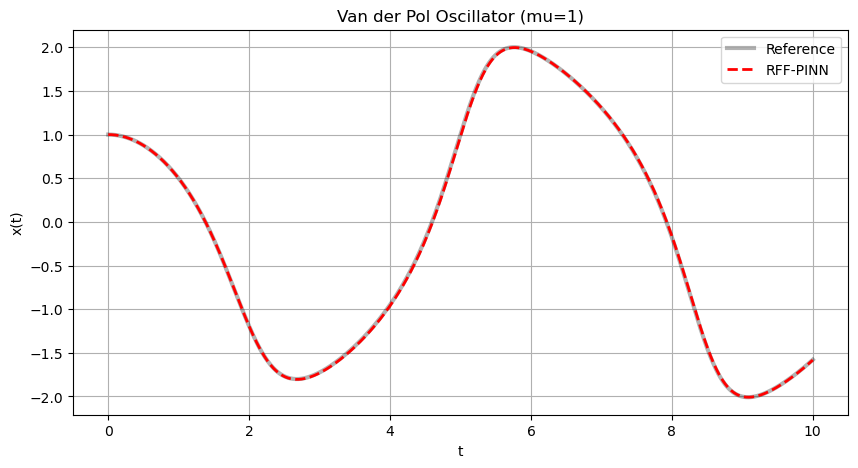

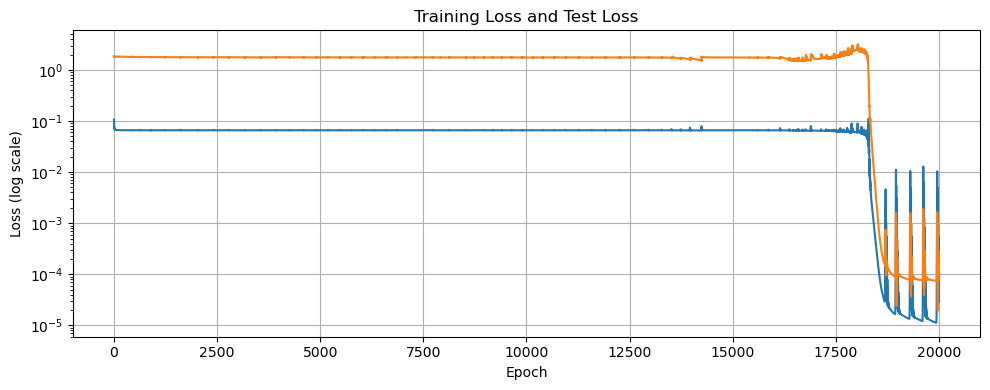

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp

# -----------------------------
# 1. Neural Network
class BasicNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)
        
# -----------------------------
# 2. Helper functions
# -----------------------------
def d_dt(x, t):
    (dt,) = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)
    return dt

def d2_dt2(x, t):
    dt = d_dt(x, t)
    dtt = d_dt(dt, t)
    return dtt

# -----------------------------
# 3. Training loop
# -----------------------------
def train_PINN(epochs, model, mu, t_min, t_max, t_test, x_test_true, x0, v0, w_ic, n_col=1000, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    test_losses = []

    # Initial time (needs grad for x'(t0))
    t0 = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)

    # Collocation points like your linspace approach (fixed, deterministic)
    t_interior_np = np.linspace(t_min, t_max, n_col + 2)[1:-1]  # exclude both boundaries
    t_interior = torch.tensor(t_interior_np, dtype=torch.float32).view(-1, 1)
    t_interior.requires_grad_(True)

    for i in range(epochs):

        x_hat = model(t_interior)
    
        # 2) residual: y'' + y - sin(pi x)
        x_pp_hat = d2_dt2(x_hat, t_interior)
        x_p_hat = d_dt(x_hat, t_interior)
    
        r = x_pp_hat - mu * (1 - x_hat**2) * x_p_hat + x_hat
        loss = torch.mean(r**2)

        # soft initial conditions penalty 
        x0_pred = model(t0)          # x(t0)
        v0_pred = d_dt(x0_pred, t0)  # x'(t0)
        loss_ic = (x0_pred - x0)**2 + (v0_pred - v0)**2

        loss = loss + w_ic * loss_ic
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        # Test Loss Calculation   
        model.eval()
        with torch.no_grad():
            x_test_pred = model(t_test)
            mse = torch.mean((x_test_pred - x_test_true)**2).item()
        model.train()

        test_losses.append(mse)

        if i % 1000 == 0:
            print(f"Epoch {i} | Train: {loss.item():} | Test MSE: {mse:}")

    return model, train_losses, test_losses

# -----------------------------
# 4. Execution
# -----------------------------
mu = 1
t_min, t_max = 0.0, 10.0
x0, v0 = 1.0, 0.0

# Reference
t_ref = np.linspace(0, 10, 1000)
sol = solve_ivp(lambda t, z: [z[1], mu*(1-z[0]**2)*z[1]-z[0]], [0, 10], [1.0, 0.0], t_eval=t_ref)

x_ref = sol.y[0]

# Test tensors
t_test = torch.tensor(t_ref, dtype=torch.float32).view(-1, 1)
x_test_true = torch.tensor(x_ref, dtype=torch.float32).view(-1, 1)

torch.manual_seed(0)
model = BasicNetwork()
trained_model, train_loss_history, test_loss_history = train_PINN(epochs=20000, model=model, mu=mu, t_min=t_min, t_max=t_max, t_test=t_test,
                                                                    x_test_true=x_test_true, x0=x0, v0=v0, w_ic=0.1)

# Train Model
trained_model.eval()

t_plot = torch.linspace(t_min, t_max, 1000).reshape(-1, 1).requires_grad_(True)

x_pinn = trained_model(t_plot).detach().numpy().reshape(-1)

# Plot Results
plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[0], 'k-', alpha=0.3, lw=3, label="Reference")
plt.plot(sol.t, x_pinn, 'r--', lw=2, label="RFF-PINN")
plt.title(f"Van der Pol Oscillator (mu={mu})") 
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.semilogy(train_loss_history, label="Train (physics + IC)")
plt.semilogy(test_loss_history, label="Test (MSE vs reference)")
plt.title("Training Loss and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gamma Comparison

In [77]:
# -----------------------------
# Compare different w_ic values (store train + test loss)
# -----------------------------
mu = 1  # fixed
w_ic_values = [0.0, 0.01, 0.1, 1, 10, 100]

all_train_losses = {}  # {w_ic: [train_loss over epochs]}
all_test_losses  = {}  # {w_ic: [test_mse over epochs]}

for w_val in w_ic_values:
    print(f"\nTraining for w_ic = {w_val}")

    torch.manual_seed(0)  # same init for fair comparison
    model = BasicNetwork()

    _, train_hist, test_hist = train_PINN(epochs=20000, model=model, mu=mu, t_min=t_min, t_max=t_max,
                                          t_test=t_test, x_test_true=x_test_true, x0=x0, v0=v0, w_ic=w_val, n_col=1000, lr=1e-3)

    all_train_losses[w_val] = train_hist
    all_test_losses[w_val]  = test_hist

# -----------------------------
# Plot: Train loss curves for each w_ic
# -----------------------------
plt.figure(figsize=(10, 4))
for w_val in w_ic_values:
    plt.semilogy(all_train_losses[w_val], label=f"w_ic={w_val}")
plt.title(f"Train Loss (physics + w_ic*IC), mu={mu}")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot: Test MSE curves for each w_ic
# -----------------------------
plt.figure(figsize=(10, 4))
for w_val in w_ic_values:
    plt.semilogy(all_test_losses[w_val], label=f"w_ic={w_val}")
plt.title(f"Test Loss (MSE vs reference), mu={mu}")
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Training for w_ic = 0.0


TypeError: train_PINN() got an unexpected keyword argument 'w_ic'

## Graph Just for report(Must be run in correct order)

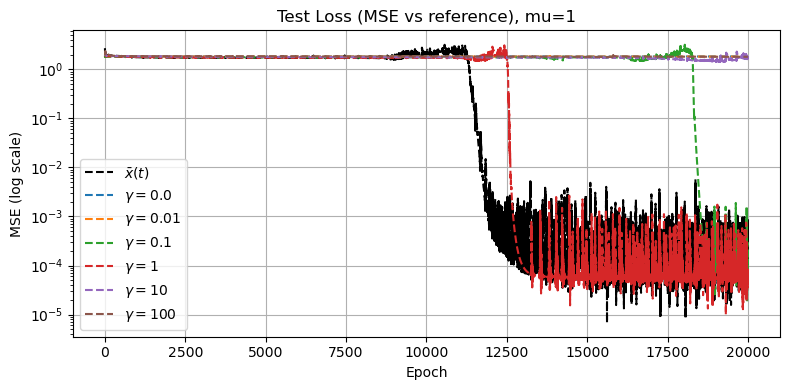

In [75]:
plt.figure(figsize=(8, 4))

plt.semilogy(test_loss_history, label=rf"$\bar{{x}}(t)$", ls='--', color = 'black')

for w_val in w_ic_values:
    plt.semilogy(all_test_losses[w_val], label=rf"$\gamma={w_val}$", ls='--')


plt.title(f"Test Loss (MSE vs reference), mu={mu}")
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("test_loss_plot.png", dpi=300, bbox_inches="tight")
plt.show()